# Tobii

## Setup

In [1]:
import sys
import os
from IPython.display import Image
import pandas as pd

# Replace with the actual path to your pyxations package
package_path = "../pyxations"
sys.path.append(package_path)

In [2]:
import pyxations as pyx

## Dataset to BIDS

The filenames in the dataset folder are assumed to have the following structure for Tobii data.

In [3]:
current_folder = os.getcwd()
current_folder = os.path.join(os.path.dirname(current_folder),"tests","data")
files_folder_path = os.path.join(current_folder,"tobii_files")
bids_dataset_folder = pyx.dataset_to_bids(current_folder,files_folder_path,"tobii_dataset", format_name='tobii')

In [4]:
print(bids_dataset_folder)

D:\OneDrive - UBA\pyxations\tests\data\tobii_dataset


## Compute derivatives

In [5]:
dataset_type = 'tobii'
detection_algorithm = 'remodnav'
pyx.compute_derivatives_for_dataset(bids_dataset_folder, dataset_type, detection_algorithm, 
                                    overwrite=True)

WindowsPath('D:/OneDrive - UBA/pyxations/tests/data/tobii_dataset_derivatives')

## Load data and plots

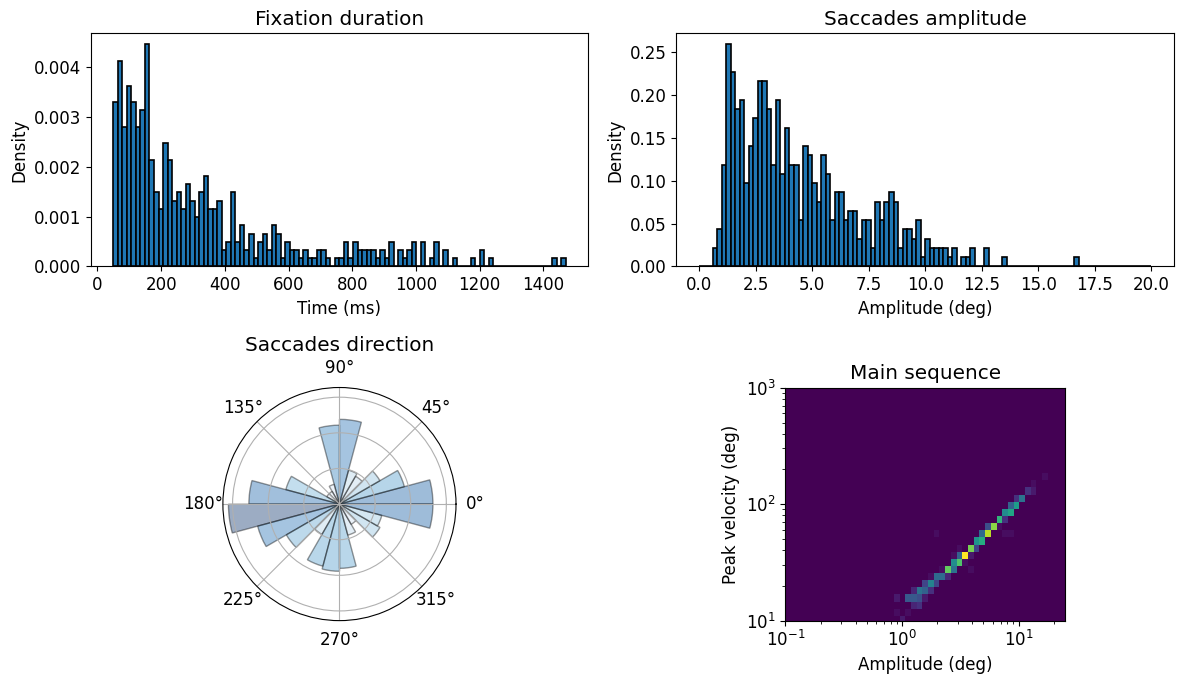

In [6]:
exp = pyx.Experiment(bids_dataset_folder)
exp.load_data("remodnav")

# Some plots
exp.plot_multipanel(True)

In [7]:
exp.subjects

{'0001': Subject = '0001', Experiment = 'tobii_dataset'}

In [8]:
exp.subjects['0001'].sessions

{'sceneviewing': Session = 'sceneviewing', Subject = '0001', Experiment = 'tobii_dataset'}

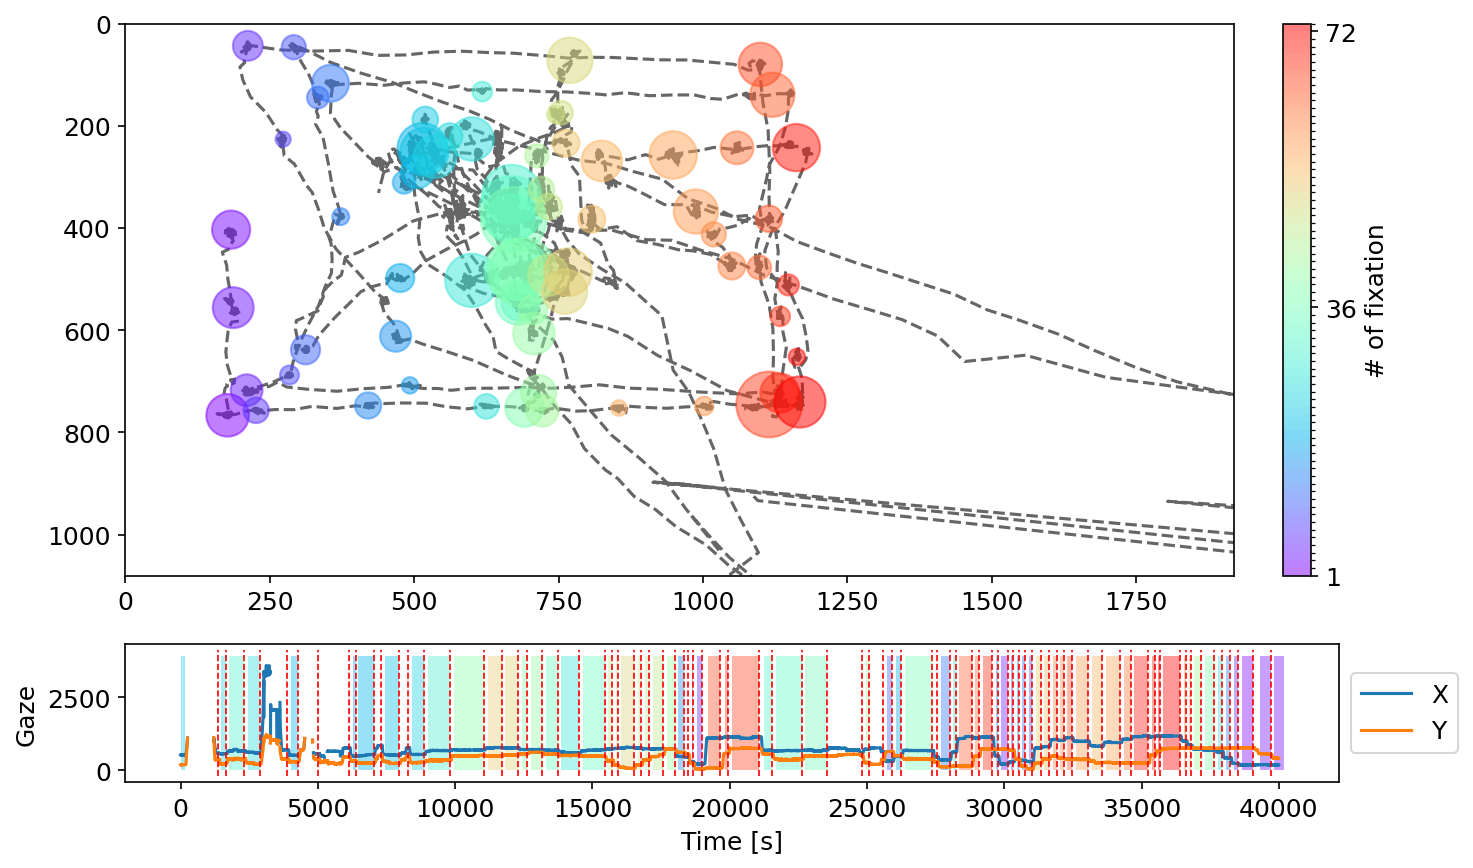

In [9]:
# The whole recording is treated as a single "complete_recording" trial.
# plot_scanpath assigns one colour per fixation and caps at 256, so we plot a
# time window (first 40 s) instead of all fixations. Tobii Gaze2d is already in
# screen pixels, so we pass the screen resolution (height, width).
trial = exp.subjects['0001'].get_trial(session_id='sceneviewing', trial_number=0)
fix = trial.fixations()
t0 = fix['tStart'].min()
trial.plot_scanpath(1080, 1920, tmin=t0, tmax=t0 + 40000)

In [10]:
# Retrieve data for the trial
exp.get_trial(subject_id='0001', session_id='sceneviewing', trial_number=0).fixations()

tStart,tEnd,xStart,yStart,xEnd,yEnd,ampDeg,vPeak,med_vel,avg_vel,duration,xAvg,yAvg,pupilAvg,Eyes_recorded,Rate_recorded,eye,phase,trial_number,trial_label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,i64,str
41481.879639,41645.194336,162.99918,325.302227,164.261238,335.430096,0.186808,11.386395,2.351925,3.431635,163.314487,163.06661,328.158125,3.364503,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
39852.067871,40272.019287,173.279749,766.21442,179.823541,769.196074,0.131621,4.478377,0.569093,0.915347,419.951538,176.970686,766.576069,3.5508478,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
41035.264648,41371.892334,182.735348,402.624768,181.514335,392.914749,0.179126,11.217887,1.33986,2.364314,336.62782,182.973936,403.281543,3.491599,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
40518.657471,40905.279541,191.325383,555.786495,180.060801,547.956377,0.251098,11.191983,1.818918,2.696478,386.622051,186.622627,555.958023,3.574371,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
31093.078613,31326.38501,195.618321,719.432035,218.03629,713.883138,0.422708,16.290098,1.127116,3.424942,233.30641,209.914481,717.46583,3.43889,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
172080.142334,172150.134277,1155.72853,310.355383,1156.523209,342.054202,0.580378,19.254277,11.066928,10.523139,69.991923,1157.7419,330.224,3.372302,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
149029.468994,149106.126709,1160.05423,133.366587,1158.110184,129.730241,0.075472,23.668167,12.971085,12.058387,76.65782,1138.468864,134.110255,3.332989,"""L""",300.034619,"""L""","""complete_recording""",0,""""""
36812.418457,36875.744629,1164.666356,661.678014,1164.026527,658.622507,0.057139,21.562442,8.641663,9.601246,63.326026,1162.5205,652.223056,3.319824,"""L""",300.034619,"""L""","""complete_recording""",0,""""""


## Animation

In [11]:
# Animate straight from the `trial` we already loaded above
trial.plot_animation(
    screen_height=1080, screen_width=1920,
    seconds_to_show=5, fps=30,
    output_format='html', display=True,
)